In [ ]:
import os

if not os.path.exists("/content/dataset"):
    !pip install datasets transformers[torch] librosa evaluate jiwer accelerate torchaudio
else:
    print("Dependencies already installed.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 63.8 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

zip_path = "/content/drive/MyDrive/ne_np_female.zip"
extract_path = "/content/dataset"

if not os.path.exists(extract_path):
    os.makedirs(extract_path)
    !unzip -q {zip_path} -d {extract_path}
    print("Extraction Complete!")
else:
    print("Dataset already extracted.")

Mounted at /content/drive
Extraction Complete!


In [ ]:
import pandas as pd
import os
from datasets import Dataset, Audio

audio_dir = "/content/drive/MyDrive/ne_np_female/wavs"
tsv_path = "/content/drive/MyDrive/ne_np_female/line_index.tsv"

# Load the TSV file
df = pd.read_csv(tsv_path, sep="\t", header=None, names=["audio_id", "sentence"])

df["audio"] = df["audio_id"].apply(lambda x: os.path.join(audio_dir, f"{x}.wav"))

# Filter to ensure we only keep rows where the file actually exists
df = df[df["audio"].apply(os.path.exists)].reset_index(drop=True)

print(f"Total valid audio files found: {len(df)}")
print(f"Sample path: {df['audio'].iloc[0]}")

# Convert to HuggingFace format
dataset = Dataset.from_pandas(df)
dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))

dataset = dataset.train_test_split(test_size=0.1)

Total valid audio files found: 2064
Sample path: /content/drive/MyDrive/ne_np_female/wavs/nep_0258_0119737288.wav


In [ ]:
!python --version
!pip show torch
!pip show torchaudio

Python 3.13.15
Name: torch
Version: 2.11.0+cu128
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: /usr/local/lib/python3.13/dist-packages
Requires: cuda-bindings, cuda-toolkit, filelock, fsspec, jinja2, networkx, nvidia-cudnn-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvshmem-cu12, setuptools, sympy, triton, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchdata, torchvision
Name: torchaudio
Version: 2.11.0+cu128
Summary: An audio package for PyTorch
Home-page: https://github.com/pytorch/audio
Author: Soumith Chintala, David Pollack, Sean Naren, Peter Goldsborough, Moto Hira, Caroline Chen, Jeff Hwang, Zhaoheng Ni, Xiaohui Zhang
Author-email: soumith@pytorch.org
License: 
Location: /usr/local/lib/python3.13/dist-packages
Requires: 
Required-by: 


In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
import torchaudio

print("TorchAudio:", torchaudio.__version__)

TorchAudio: 2.11.0+cu128


In [ ]:
from transformers import WhisperFeatureExtractor, WhisperTokenizer, WhisperProcessor

model_id = "openai/whisper-tiny"

feature_extractor = WhisperFeatureExtractor.from_pretrained(model_id)
tokenizer = WhisperTokenizer.from_pretrained(model_id, language="nepali", task="transcribe")
processor = WhisperProcessor.from_pretrained(model_id, language="nepali", task="transcribe")

def prepare_dataset(batch):
    audio = batch["audio"]
    batch["input_features"] = feature_extractor(audio["array"], sampling_rate=audio["sampling_rate"]).input_features[0]
    batch["labels"] = tokenizer(batch["sentence"]).input_ids
    return batch

dataset = dataset.map(
    prepare_dataset,
    remove_columns=dataset.column_names["train"],
    num_proc=1
)


dataset.save_to_disk("/content/drive/MyDrive/processed_nepali_dataset")
print("Dataset processed and saved to Drive!")

Map:   0%|          | 0/1857 [00:00<?, ? examples/s]

Map:   0%|          | 0/207 [00:00<?, ? examples/s]

Saving the dataset (0/4 shards):   0%|          | 0/1857 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/207 [00:00<?, ? examples/s]

Dataset processed and saved to Drive!


In [ ]:
import torch
import os
from dataclasses import dataclass
from typing import Any, Dict, List, Union
from transformers import WhisperForConditionalGeneration, Seq2SeqTrainingArguments, Seq2SeqTrainer
import evaluate

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any
    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_features": feature["input_features"]} for feature in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")
        label_features = [{"input_ids": feature["labels"]} for feature in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)
        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():
            labels = labels[:, 1:]
        batch["labels"] = labels
        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)

model = WhisperForConditionalGeneration.from_pretrained(model_id)
model.to(device)

model.config.forced_decoder_ids = processor.get_decoder_prompt_ids(language="nepali", task="transcribe")
model.config.suppress_tokens = []
model.config.use_cache = False 

metric = evaluate.load("wer")
def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids
    label_ids[label_ids == -100] = tokenizer.pad_token_id
    pred_str = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = tokenizer.batch_decode(label_ids, skip_special_tokens=True)
    wer = 100 * metric.compute(predictions=pred_str, references=label_str)
    return {"wer": wer}

SAVE_PATH = "/content/drive/MyDrive/nepali_whisper_tiny_trained"

training_args = Seq2SeqTrainingArguments(
    output_dir=SAVE_PATH,
    per_device_train_batch_size=16,
    gradient_accumulation_steps=1,  
    learning_rate=1e-5,
    warmup_steps=50,
    max_steps=1000,
    eval_strategy="steps",
    save_strategy="steps",
    predict_with_generate=True,
    generation_max_length=225,
    save_steps=100,              
    eval_steps=100,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,
    fp16=True,                   
    use_cpu=False,                
    gradient_checkpointing=True,
    save_total_limit=2,
    report_to="none"
)

trainer = Seq2SeqTrainer(
    args=training_args,
    model=model,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=processor.feature_extractor,
)

try:
    if os.path.isdir(SAVE_PATH) and any("checkpoint" in d for d in os.listdir(SAVE_PATH)):
        print("--- Resuming from last checkpoint ---")
        trainer.train(resume_from_checkpoint=True)
    else:
        print("--- Starting fresh training ---")
        trainer.train()
except KeyboardInterrupt:
    print("\n--- Training interrupted. Saving current state... ---")
    trainer.save_model(os.path.join(SAVE_PATH, "interrupted_backup"))
except Exception as e:
    print(f"\n--- An error occurred: {e} ---")
finally:
    print("--- Saving final model and processor ---")
    trainer.save_model(SAVE_PATH)
    processor.save_pretrained(SAVE_PATH)

Using device: cuda


model.safetensors: reconstructing file:   0%|          |  0.00B /  151MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.75k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['proj_out.weight'].


--- Saving final model and processor ---


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
import torch

input_features = torch.tensor([sample["input_features"]]).to(device)


with torch.no_grad():
    predicted_ids = model.generate(input_features)

transcription = processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]

print(f"--- TEST RESULT ---")
print(f"Actual: {tokenizer.decode(sample['labels'], skip_special_tokens=True)}")
print(f"Predicted: {transcription}")

--- TEST RESULT ---
Actual: यसरी प्याङको छुट्टै पहिचान बनाइसकेको ती नाचको परम्परा समयको कालखण्डमा अस्तित्वमै नभएको दुःखलाग्दो विषय भयो
Predicted: यसरी प्याङ्को छुट्य पहिचान वनिसकैको ती नाँचको परमपरा समयको काल थण्डमा अस्थितो मै नवभैको दुखलाग्द विशय भयो


In [ ]:
import shutil
from google.colab import files

print("Zipping model... this may take a minute.")
shutil.make_archive("nepali_whisper_best", "zip", "/content/drive/MyDrive/nepali_whisper_tiny_trained")

files.download("nepali_whisper_best.zip")
print("Download started!")

Zipping model... this may take a minute.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started!


THIS IS THE CODE I USED AFTER THE RUNTIME GOT DISCONNECTED BY LOADING THE SAVED MODEL


In [1]:
!pip install transformers torch accelerate librosa evaluate jiwer

from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 59.8 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
from transformers import pipeline
import torch
import os

MODEL_PATH = "/content/drive/MyDrive/nepali_whisper_tiny_trained"

AUDIO_FILE = "/content/biaudio2.wav"

if not os.path.exists(MODEL_PATH):
    print("Model path not found in Drive. Check My Drive/nepali_whisper_tiny_trained")
elif not os.path.exists(AUDIO_FILE):
    print(f"Audio file not found at {AUDIO_FILE}. Please upload it to the sidebar.")
else:
    device = 0 if torch.cuda.is_available() else -1

    pipe = pipeline(
        "automatic-speech-recognition",
        model=MODEL_PATH,
        chunk_length_s=30,
        device=device
    )

    print("Transcribing with your fine-tuned model...")


    result = pipe(
        AUDIO_FILE,
        return_timestamps=True,
        generate_kwargs={
            "language": "nepali",
            "task": "transcribe",
            "repetition_penalty": 1.2
        }
    )

    print("\n" + "="*50)
    print("YOUR TRAINED MODEL TRANSCRIPTION:")
    print("-" * 50)
    print(result["text"])
    print("="*50)

Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

[transformers] Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


Transcribing with your fine-tuned model...


[transformers] Passing `generation_config` together with generation-related arguments=({'repetition_penalty'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The 


YOUR TRAINED MODEL TRANSCRIPTION:
--------------------------------------------------
देरे समन पैले उटा सानलाउमा सोफिया नामकि व्टिव्टया लोकेटिबस्थिन सफियाला पूल्ड व्रिर्वहरू तरेभन्पर्थेँ एक्दिन जंजम्छ्को चुचिउमा किल्लेग्दा अवस्लेउटा उइलाई एको अनो टोनिएल्फट्देखिन्


In [3]:
from transformers import pipeline
import torch
import os

MODEL_PATH = "/content/drive/MyDrive/nepali_whisper_tiny_trained"

AUDIO_FILE = "/content/tiaudio.wav"

if not os.path.exists(MODEL_PATH):
    print("Model path not found in Drive. Check My Drive/nepali_whisper_tiny_trained")
elif not os.path.exists(AUDIO_FILE):
    print(f"Audio file not found at {AUDIO_FILE}. Please upload it to the sidebar.")
else:
    device = 0 if torch.cuda.is_available() else -1

    pipe = pipeline(
        "automatic-speech-recognition",
        model=MODEL_PATH,
        chunk_length_s=30,
        device=device
    )

    print("Transcribing with your fine-tuned model...")


    result = pipe(
        AUDIO_FILE,
        return_timestamps=True,
        generate_kwargs={
            "language": "nepali",
            "task": "transcribe",
            "repetition_penalty": 1.2
        }
    )

    print("\n" + "="*50)
    print("YOUR TRAINED MODEL TRANSCRIPTION:")
    print("-" * 50)
    print(result["text"])
    print("="*50)

Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

[transformers] Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


Transcribing with your fine-tuned model...


[transformers] Whisper did not predict an ending timestamp, which can happen if audio is cut off in the middle of a word. Also make sure WhisperTimeStampLogitsProcessor was used during generation.



YOUR TRAINED MODEL TRANSCRIPTION:
--------------------------------------------------
म्प्रिशाहो मयलिकाम गरेराको छुए मलाकाम गर्न र महिरो लाइराको छ


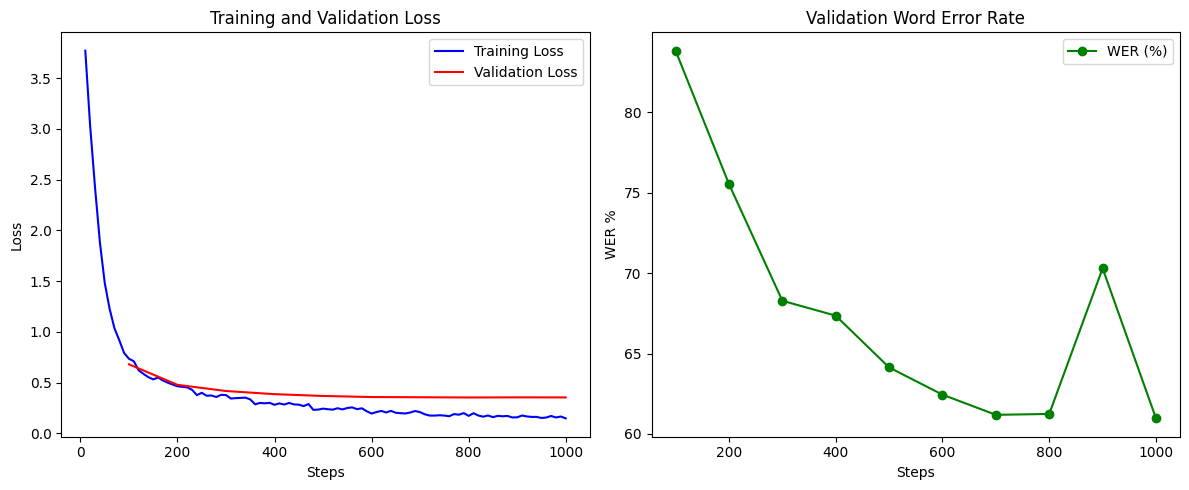

Graphs saved to your Drive as 'training_graphs.png'


In [ ]:
import matplotlib.pyplot as plt

history = trainer.state.log_history

train_loss = [log["loss"] for log in history if "loss" in log]
train_steps = [log["step"] for log in history if "loss" in log]

eval_loss = [log["eval_loss"] for log in history if "eval_loss" in log]
eval_wer = [log["eval_wer"] for log in history if "eval_wer" in log]
eval_steps = [log["step"] for log in history if "eval_loss" in log]

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(train_steps, train_loss, label="Training Loss", color="blue")
plt.plot(eval_steps, eval_loss, label="Validation Loss", color="red")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# WER 
plt.subplot(1, 2, 2)
plt.plot(eval_steps, eval_wer, label="WER (%)", color="green", marker='o')
plt.xlabel("Steps")
plt.ylabel("WER %")
plt.title("Validation Word Error Rate")
plt.legend()

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/nepali_whisper_tiny_trained/training_graphs.png")
plt.show()

print("Graphs saved to your Drive as 'training_graphs.png'")

I USED THE PREBUILT MODEL WHISPER-LARGE HERE (NOT MY MODEL)

In [ ]:
from transformers import pipeline
import torch

better_pipe = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-large-v3-turbo",
    chunk_length_s=30,
    device=0
)


result = better_pipe(
    "/content/biaudio2.wav",
    return_timestamps=True,
    generate_kwargs={"language": "nepali", "task": "transcribe"},
    batch_size=8
)

print("\n" + "="*50)
print("WHISPER LARGE-V3-TURBO RESULT:")
print("-" * 50)
print(result["text"])
print("="*50)

Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]

[transformers] Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).



WHISPER LARGE-V3-TURBO RESULT:
--------------------------------------------------
 देराई समय पहिले उटा सान अगाउमा सोफिया नामकी उट्टि दयालो केटी बस्थेन, सोफिया लेफ फोल्ड बिरुवा हरु धरे मन पर्थे, एक दिन जंगल कोछे उमा खेल लेगा दाउसले उटा, उईलाई एको अनाउठ नील फोल देखीन।


In [ ]:
from transformers import pipeline
import torch

better_pipe = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-large-v3-turbo",
    chunk_length_s=30,
    device=0
)

result = better_pipe(
    "/content/tiaudio.wav",
    return_timestamps=True,
    generate_kwargs={"language": "nepali", "task": "transcribe"},
    batch_size=8
)

print("\n" + "="*50)
print("WHISPER LARGE-V3-TURBO RESULT:")
print("-" * 50)
print(result["text"])
print("="*50)

Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]

[transformers] Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).



WHISPER LARGE-V3-TURBO RESULT:
--------------------------------------------------
 आम पिसाओ, मो अहिले काम गरी राको छू, मला काम गर्ना रमाहिलो लाई राको छू
